# Batter Model Hyperparameter Tuning
Optuna-based search for the best `MVTBatterModel` configuration.
The winning model, scaler, and metadata are saved to `results/batter_model/`.

In [1]:
# Configuration Parameters
N_TRIALS = 5            # Optuna trials (start small, increase later)
NUM_EPOCHS = 100        # Max epochs per trial (early stopping will cut short)
PATIENCE = 15           # Early stopping patience
DEVICE = 'mps'          # 'mps' for Apple Silicon, 'cpu' for fallback
MIN_QUAL_PA = 50        # Minimum plate appearances in target season
RESULTS_DIR = './results/batter_model/'

In [2]:
import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import optuna

from src.mvt_batter_model import MVTBatterModel, MVTBatterDataset

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Load data
csv_path = './data/batting_stats.csv'
need_download = True
if os.path.exists(csv_path):
    data = pd.read_csv(csv_path)
    if 'PA' in data.columns:
        need_download = False
        print(f'Found {csv_path} with {len(data)} rows.')

if need_download:
    print(f'{csv_path} missing — downloading via pybaseball.')
    from pybaseball import batting_stats
    data = batting_stats(start_season=2015, end_season=2025, qual=10)
    data.to_csv(csv_path, index=False)
    print(f'Saved {len(data)} rows to {csv_path}.')

Found ./data/batting_stats.csv with 5873 rows.


In [3]:
# Fantasy score map (used for final evaluation, not training loss)
score_map = {
    'R': 0.75,
    '1B': 1,
    '2B': 1.5,
    '3B': 2,
    'HR': 3,
    'RBI': 0.75,
    'BB': 1,
    'SO': -0.5,
    'HBP': 1,
    'SB': 1,
    'CS': -2,
    'GDP': -2,
}

aux_features = [
    'PA', 'AB', 'xwOBA', 'OPS', 'ISO', 'OBP',
    'O-Swing%', 'Z-Swing%', 'Swing%', 'O-Contact%', 'Z-Contact%',
    'Contact%', 'Zone%', 'SwStr%', 'BsR',
    'LD%', 'GB%', 'FB%', 'HR/FB', 'Hard%', 'GB/FB', 'Barrel%',
]

features = list(score_map.keys()) + aux_features

device = torch.device(DEVICE if DEVICE == 'mps' and torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Features: {len(features)}')

Using device: mps
Features: 34


In [4]:
def prepare_data(X, y_features, features_list, batch_size=32):
    """
    StandardScaler on sequences, per-feature target normalization, 80/20 split.
    Returns loaders, scaler, and feature_stats dict.
    """
    X_np = X.cpu().numpy()
    num_sequences, seq_len, num_features = X_np.shape

    # Scale sequences
    X_reshaped = X_np.reshape(-1, num_features)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_reshaped).reshape(num_sequences, seq_len, num_features)
    X_scaled = torch.tensor(X_scaled, dtype=torch.float32)

    # Per-feature target normalization
    y_np = y_features.cpu().numpy()
    feature_stats = {}
    y_norm = np.zeros_like(y_np)
    for i, name in enumerate(features_list):
        mean = float(np.mean(y_np[:, i]))
        std = float(np.std(y_np[:, i]))
        feature_stats[name] = (mean, std)
        y_norm[:, i] = (y_np[:, i] - mean) / (std + 1e-8)
    y_norm = torch.tensor(y_norm, dtype=torch.float32)

    # 80/20 split
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y_norm, test_size=0.2, random_state=42
    )

    train_loader = DataLoader(
        TensorDataset(X_train.to(device), y_train.to(device)),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val.to(device), y_val.to(device)),
        batch_size=batch_size, shuffle=False
    )

    return train_loader, val_loader, scaler, feature_stats

In [5]:
def train_model(model, train_loader, val_loader, num_epochs=100, lr=1e-3, patience=15):
    """
    Train MVTBatterModel with MSE loss on all features. Returns best val loss.
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val_loss

In [6]:
# Build dataset once (default nlookbacks=5 for dataset creation;
# the model's nlookbacks param matches whatever the dataset produces)
mvt_dataset = MVTBatterDataset(
    data=data, features=features, nlookbacks=5, min_qual_pa=MIN_QUAL_PA
)
X = mvt_dataset.sequences
y_features = mvt_dataset.targets_features
print(f'Dataset: {X.shape}')


def objective(trial):
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4, 8])
    if d_model % nhead != 0:
        raise optuna.TrialPruned()

    num_layers = trial.suggest_int('num_layers', 1, 4)
    dim_feedforward = trial.suggest_categorical('dim_feedforward', [64, 128, 256, 512])
    dropout = trial.suggest_float('dropout', 0.05, 0.4)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    nlookbacks = trial.suggest_int('nlookbacks', 3, 8)

    # Rebuild dataset with this nlookbacks
    ds = MVTBatterDataset(
        data=data, features=features, nlookbacks=nlookbacks, min_qual_pa=MIN_QUAL_PA
    )

    train_loader, val_loader, _, _ = prepare_data(
        ds.sequences, ds.targets_features, features, batch_size=batch_size
    )

    model = MVTBatterModel(
        input_dim=len(features),
        num_features=len(features),
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        nlookbacks=nlookbacks,
    )

    val_loss = train_model(
        model, train_loader, val_loader,
        num_epochs=NUM_EPOCHS, lr=lr, patience=PATIENCE,
    )
    return val_loss

Dataset: torch.Size([4325, 5, 34])


In [7]:
print('Running hyperparameter search...')
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=N_TRIALS)
print(f'Best val loss: {study.best_value:.6f}')

Running hyperparameter search...
Best val loss: 0.606631


In [8]:
print('=== Best Trial ===')
print(f'  Val loss: {study.best_value:.6f}')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

=== Best Trial ===
  Val loss: 0.606631
  d_model: 64
  nhead: 2
  num_layers: 3
  dim_feedforward: 64
  dropout: 0.17077796710095788
  lr: 0.00010883853187725637
  batch_size: 64
  nlookbacks: 8


In [9]:
# Retrain best model from scratch
p = study.best_params
nlookbacks = p['nlookbacks']

best_ds = MVTBatterDataset(
    data=data, features=features, nlookbacks=nlookbacks, min_qual_pa=MIN_QUAL_PA
)
train_loader, val_loader, scaler, feature_stats = prepare_data(
    best_ds.sequences, best_ds.targets_features, features, batch_size=p['batch_size']
)

best_model = MVTBatterModel(
    input_dim=len(features),
    num_features=len(features),
    d_model=p['d_model'],
    nhead=p['nhead'],
    num_layers=p['num_layers'],
    dim_feedforward=p['dim_feedforward'],
    dropout=p['dropout'],
    nlookbacks=nlookbacks,
)

train_model(
    best_model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=p['lr'], patience=PATIENCE,
)

# Evaluate on validation set — per-feature metrics (denormalized)
best_model.eval()
best_model.to(device)
all_preds, all_actuals = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        preds = best_model(X_batch)
        all_preds.extend(preds.cpu().numpy())
        all_actuals.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_actuals = np.array(all_actuals)

# Denormalize
preds_denorm = np.zeros_like(all_preds)
actuals_denorm = np.zeros_like(all_actuals)
for i, fname in enumerate(features):
    mean, std = feature_stats[fname]
    preds_denorm[:, i] = all_preds[:, i] * std + mean
    actuals_denorm[:, i] = all_actuals[:, i] * std + mean

print('Per-Feature Validation Metrics (denormalized):')
per_feature_metrics = {}
for i, fname in enumerate(features):
    mae = mean_absolute_error(actuals_denorm[:, i], preds_denorm[:, i])
    r2 = r2_score(all_actuals[:, i], all_preds[:, i])
    per_feature_metrics[fname] = {'mae': float(mae), 'r2': float(r2)}
    print(f'  {fname:15s} — MAE: {mae:.4f}, R²: {r2:.4f}')

# Overall MSE across all features (normalized)
overall_mse = mean_squared_error(all_actuals, all_preds)
overall_mae = mean_absolute_error(all_actuals, all_preds)
overall_r2 = r2_score(all_actuals.flatten(), all_preds.flatten())
print(f'\nOverall — MSE: {overall_mse:.4f}, MAE: {overall_mae:.4f}, R²: {overall_r2:.4f}')

Per-Feature Validation Metrics (denormalized):
  R               — MAE: 18.7178, R²: 0.3918
  1B              — MAE: 21.3353, R²: 0.3697
  2B              — MAE: 7.2997, R²: 0.3453
  3B              — MAE: 1.1963, R²: 0.2316
  HR              — MAE: 6.0552, R²: 0.4102
  RBI             — MAE: 18.3383, R²: 0.3989
  BB              — MAE: 13.0490, R²: 0.4447
  SO              — MAE: 30.3844, R²: 0.2979
  HBP             — MAE: 2.3511, R²: 0.3491
  SB              — MAE: 4.0434, R²: 0.4381
  CS              — MAE: 1.2877, R²: 0.3865
  GDP             — MAE: 3.2470, R²: 0.3652
  PA              — MAE: 135.7574, R²: 0.3509
  AB              — MAE: 121.4454, R²: 0.3445
  xwOBA           — MAE: 0.0251, R²: 0.5420
  OPS             — MAE: 0.0783, R²: 0.4038
  ISO             — MAE: 0.0373, R²: 0.4106
  OBP             — MAE: 0.0285, R²: 0.4179
  O-Swing%        — MAE: 0.0325, R²: 0.5568
  Z-Swing%        — MAE: 0.0366, R²: 0.4735
  Swing%          — MAE: 0.0263, R²: 0.5564
  O-Contact%      — 

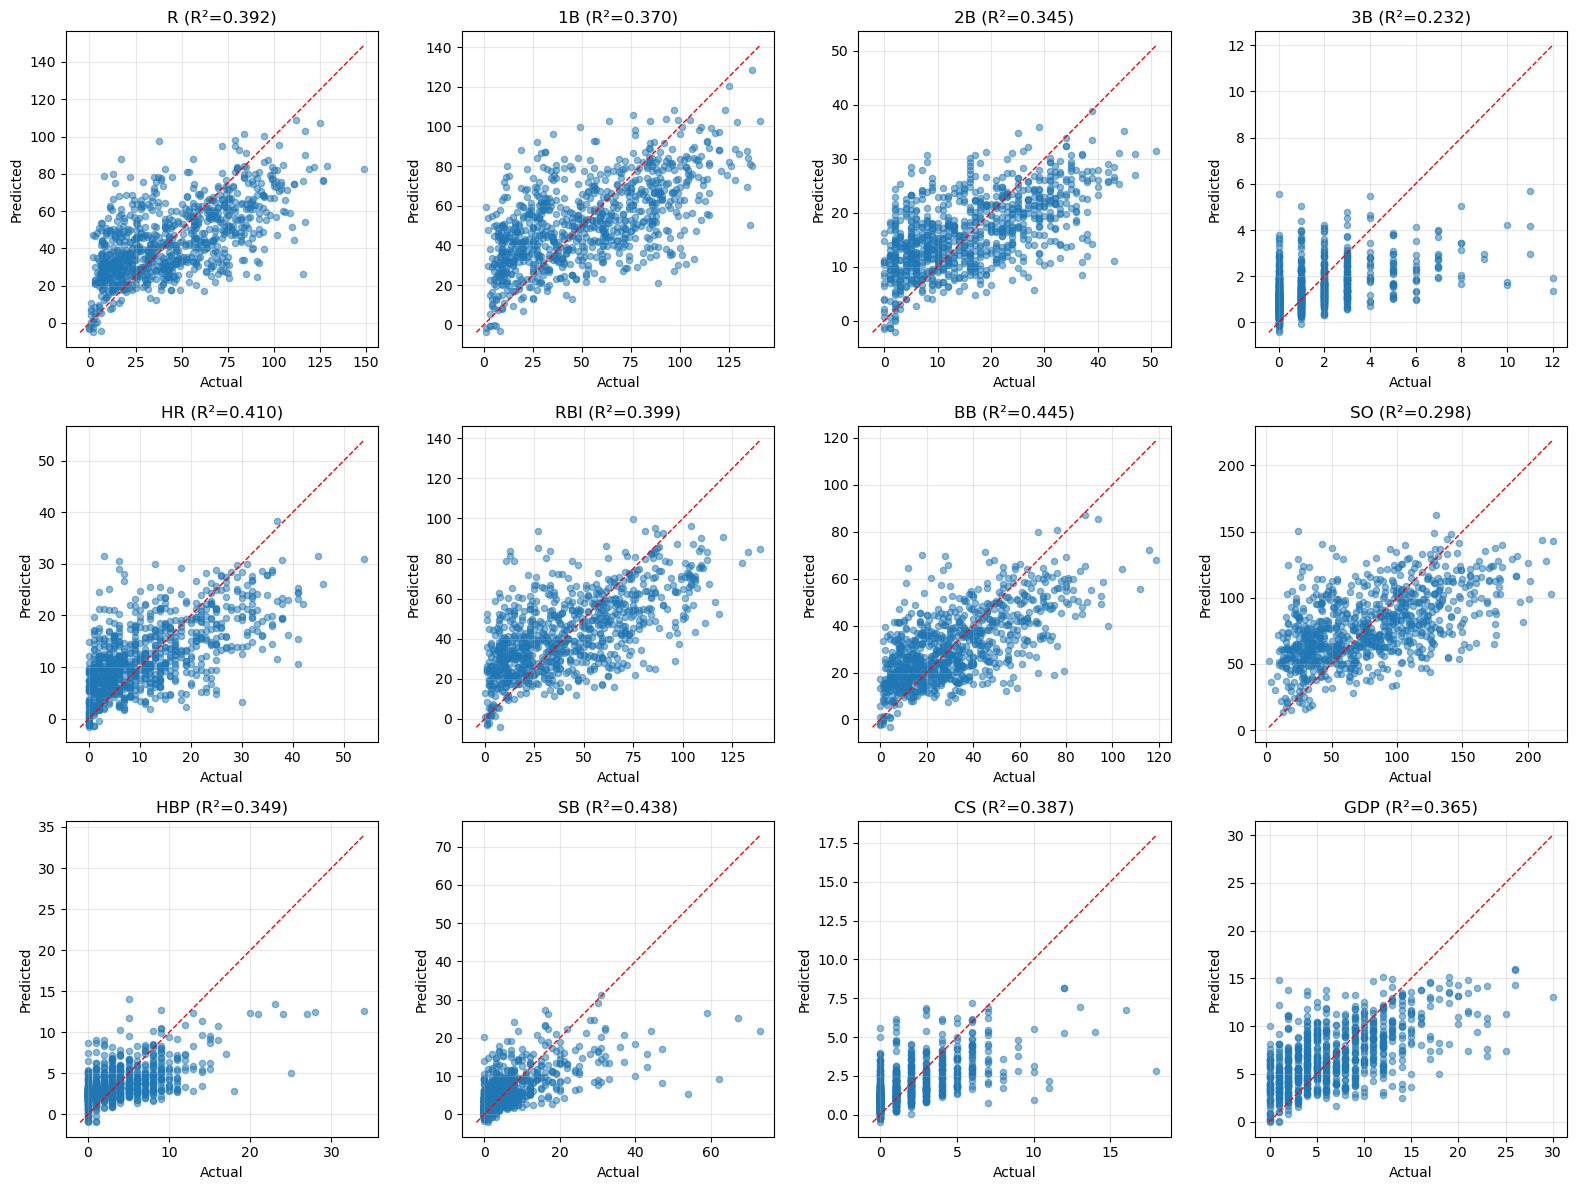

In [10]:
# Scatter plots for selected features
plot_features = list(score_map.keys())[:16]  # Fantasy-relevant features
n_plots = len(plot_features)
ncols = 4
nrows = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for idx, fname in enumerate(plot_features):
    i = features.index(fname)
    ax = axes[idx]
    ax.scatter(actuals_denorm[:, i], preds_denorm[:, i], alpha=0.5, s=20)
    lims = [
        min(actuals_denorm[:, i].min(), preds_denorm[:, i].min()),
        max(actuals_denorm[:, i].max(), preds_denorm[:, i].max()),
    ]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    r2 = per_feature_metrics[fname]['r2']
    ax.set_title(f'{fname} (R²={r2:.3f})')
    ax.grid(True, alpha=0.3)

for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save model weights
torch.save(best_model.state_dict(), os.path.join(RESULTS_DIR, 'best_model.pt'))

# Save scaler
with open(os.path.join(RESULTS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save metadata
metadata = {
    'model_type': 'MVT',
    'hyperparameters': {
        k: (float(v) if isinstance(v, (np.floating, float)) else
            int(v) if isinstance(v, (np.integer, int)) else v)
        for k, v in p.items()
    },
    'features': features,
    'score_map': score_map,
    'feature_stats': {k: list(v) for k, v in feature_stats.items()},
    'metrics': {
        'overall_mse': float(overall_mse),
        'overall_mae': float(overall_mae),
        'overall_r2': float(overall_r2),
    },
    'per_feature_metrics': per_feature_metrics,
}

with open(os.path.join(RESULTS_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved best model to {RESULTS_DIR}')
print(f'  best_model.pt, scaler.pkl, metadata.json')
print(f'  Overall — MSE: {overall_mse:.4f}, MAE: {overall_mae:.4f}, R²: {overall_r2:.4f}')

Saved best model to ./results/batter_model/
  best_model.pt, scaler.pkl, metadata.json
  Overall — MSE: 0.6055, MAE: 0.5818, R²: 0.4290
